In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Mutual information

In [2]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 35)


,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369


In [3]:
# Definisikan target dan fitur
target_columns = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# Pastikan target columns ada dalam dataset
for target in target_columns:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' tidak ditemukan dalam dataset")

# Pisahkan fitur dan target
X = df.drop(target_columns, axis=1)
y_boiler_eff = df['Boiler Eff (%)']
y_nphr = df['NPHR (Kcal/Kwh)']

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

Jumlah fitur: 33
Jumlah sampel: 549


In [4]:
# Cek apakah ada nilai yang hilang
print("\nJumlah nilai yang hilang di setiap fitur:")
print(X.isnull().sum().sort_values(ascending=False).head(10))  # Tampilkan 10 teratas



Jumlah nilai yang hilang di setiap fitur:
Main steam flow (t/h)           0
Condenser vacuum (kPa)          0
Spray reheat pressure           0
Temperature HRH                 0
Pressure HRH                    0
HHV (Kcal/Kg)                   0
Nett Load (MW)                  0
Gross Load (MW)                 0
Coal Flow (t/h)                 0
Flue Gas in Temperature (°C)    0
dtype: int64


In [5]:
# Cek tipe data fitur
print("\nTipe data fitur:")
print(X.dtypes.value_counts())


Tipe data fitur:
float64    33
Name: count, dtype: int64


In [6]:
# Hapus kolom non-numerik jika ada (untuk mutual information)
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric_cols:
    print(f"\nMenghapus kolom non-numerik: {non_numeric_cols}")
    X = X.select_dtypes(include=['number'])

In [7]:
# Feature Selection dengan Mutual Information untuk target 1: Boiler Eff (%)
print("\n=== Feature Selection untuk Boiler Eff (%) ===")


=== Feature Selection untuk Boiler Eff (%) ===


In [8]:
# Hitung skor Mutual Information
# Mutual Information mengukur seberapa banyak informasi yang diberikan sebuah fitur tentang target
# Formula dasar: MI(X; Y) = H(Y) - H(Y|X)
# di mana:
#   H(Y) = entropy target
#   H(Y|X) = conditional entropy (entropy Y setelah mengetahui X)
#   Semakin tinggi MI, semakin penting fitur tersebut untuk memprediksi target

mi_scores_boiler = mutual_info_regression(X, y_boiler_eff, random_state=42)

# Penjelasan hasil:
# - mutual_info_regression menggunakan estimasi non-parametrik
# - Setiap nilai adalah skor MI untuk satu fitur terhadap target Boiler Eff
# - Nilai berkisar 0 hingga ~0.6 (tergantung entropy target)
# - Semakin tinggi = semakin penting fitur tersebut

In [9]:
# Buat Series untuk memudahkan analisis
mi_scores_boiler_df = pd.Series(mi_scores_boiler, index=X.columns)
mi_scores_boiler_df = mi_scores_boiler_df.sort_values(ascending=False)

In [10]:
# Tampilkan 15 fitur teratas berdasarkan skor MI
print("\nfitur untuk Boiler Eff (%) berdasarkan Mutual Information:")
print(mi_scores_boiler_df)


fitur untuk Boiler Eff (%) berdasarkan Mutual Information:
HHV (Kcal/Kg)                                  0.575601
Refference Temperature (°C)                    0.384767
Coal Flow (t/h)                                0.353337
Temperature HRH                                0.335537
Reheat steam temperature (boiler side) (℃)     0.310802
Reheat steam temperature (turbine side) (℃)    0.309383
Cold Reheat Temperature (°C)                   0.296362
Main steam temperature (turbine side) (℃)      0.288190
Condenser vacuum (kPa)                         0.284275
O2 Out APH (%)                                 0.270204
Main steam temperature (boiler side) (℃)       0.269075
Flue gas temperature (℃)                       0.259763
O2 in APH (%)                                  0.249057
Flue Gas in Temperature (°C)                   0.235992
Spray reheat pressure                          0.213392
Circulating water outlet temperature (℃)       0.206735
Pressure HRH                                

In [11]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET BOILER EFF:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_boiler = scipy_entropy(np.histogram(y_boiler_eff, bins=20)[0] + 1e-10)
print(f"Target Entropy (Boiler Eff %): {target_entropy_boiler:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_boiler = mi_scores_boiler_df.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_boiler:.6f}")

# Hitung juga untuk NPHR (jika belum ada)
try:
    mi_threshold_nphr = mi_scores_nphr_df.mean()
except:
    mi_threshold_nphr = mi_threshold_boiler  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR (Boiler Eff %)")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_boiler_df
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk Boiler Eff: {mi_threshold_boiler:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_boiler:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_boiler_df > mi_threshold_boiler).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET BOILER EFF:
----------------------------------------------------------------------------------------------------
Targe

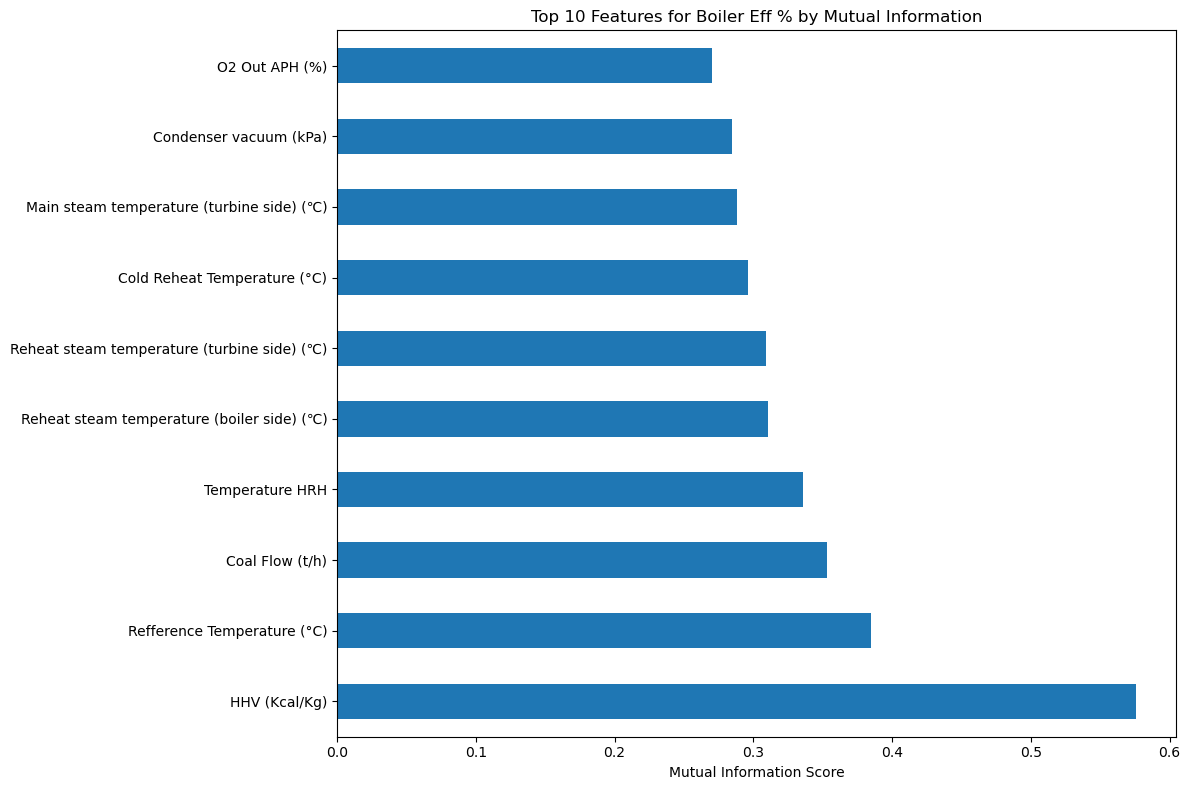

In [12]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_boiler_df.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for Boiler Eff % by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [13]:
!pip install Cython
!pip install pygad scikit-learn

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_boiler_eff)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_boiler_df, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_boiler_eff, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['Main steam flow (t/h)', 'Flue gas temperature (℃)', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'Condenser vacuum (kPa)', 'Cold Reheat Temperature (°C)', 'Refference Temperature (°C)', 'Coal Flow (t/h)', 'Gross Load (MW)', 'HHV (Kcal/Kg)']
mRMR (Information) : ['HHV (Kcal/Kg)', 'Coal Flow (t/h)', 'O2 Out APH (%)', 'Temperature HRH', 'Condenser vacuum (kPa)', 'Cold Reheat Temperature (°C)', 'Superheater desuperheating water flow (t/h)', 'Refference Temperature (°C)', 'O2 in APH (%)', 'Reheat steam temperature (boiler side) (℃)']
GA (Evolutionary)  : ['Main steam flow (t/h)', 'Main steam temperature (boiler side) (℃)', 'Reheater desuperheating water flow (t/h)', 'Control stage pressure (Mpa)', 'High exhaust pressure (Mpa)', 'Cold Reheat Pressure (Mpa)', 'O2 in APH (%)', 'Refference Temperature (°C)', 'Coal Flow (t/h)', 'Nett Loa

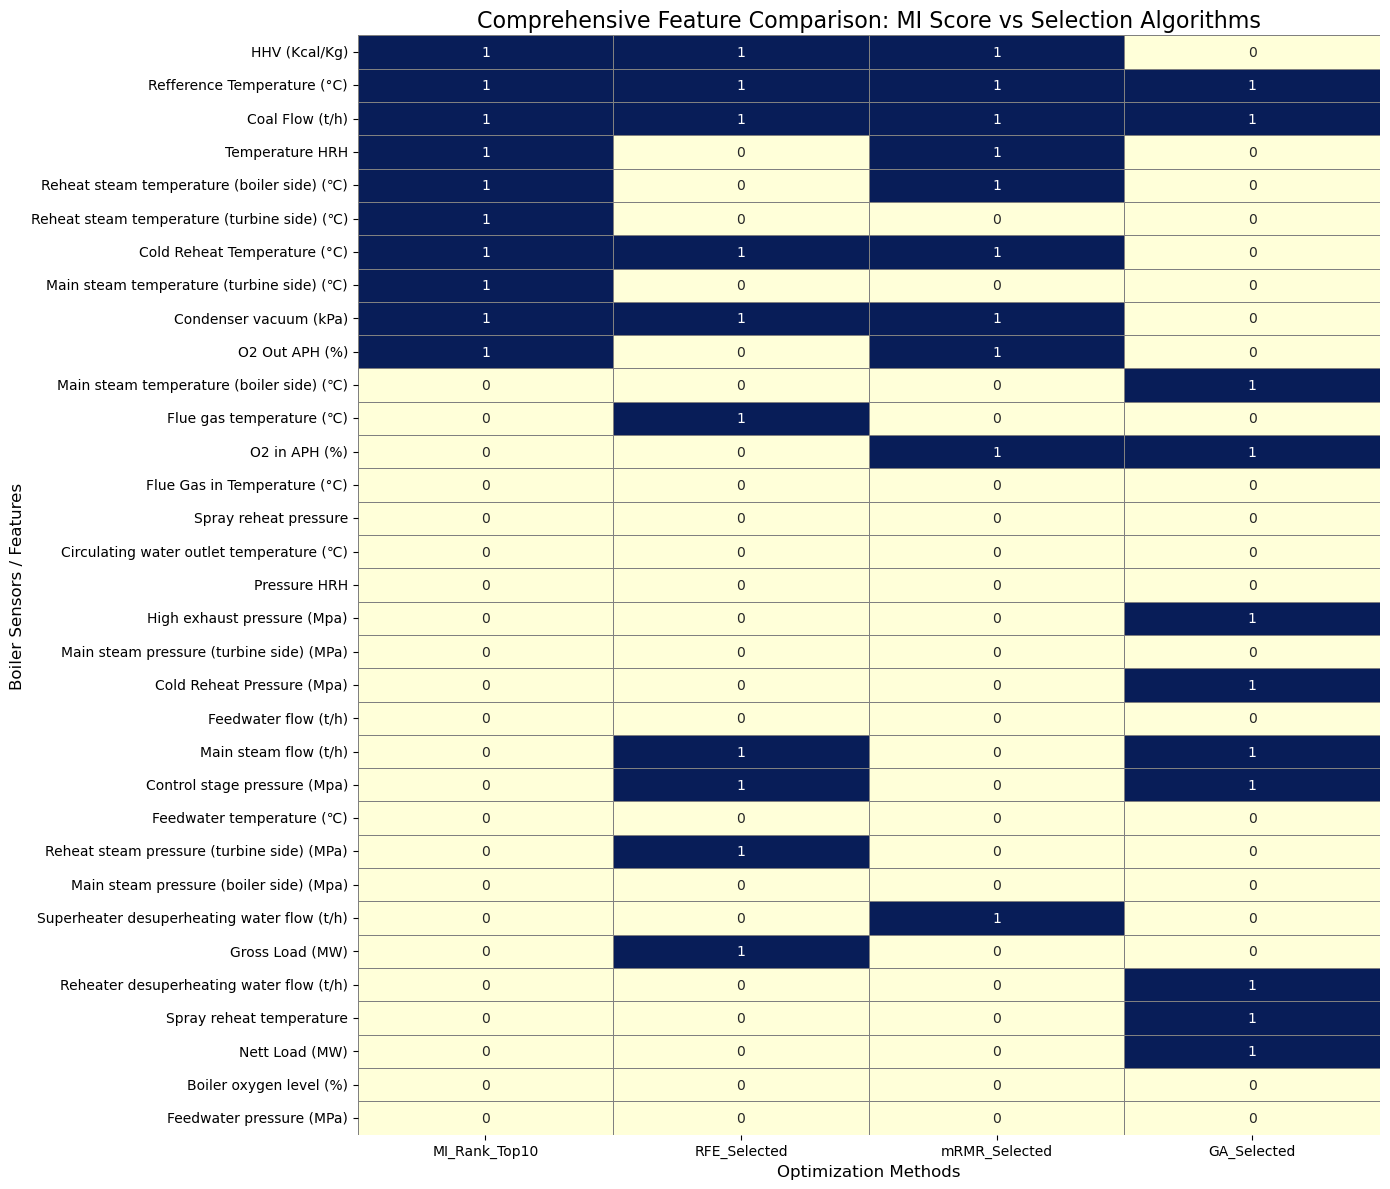


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
HHV (Kcal/Kg)                            | 0.575601   | 1      | 1     | 1     | 0     | 2
Refference Temperature (°C)              | 0.384767   | 1      | 1     | 1     | 1     | 3
Coal Flow (t/h)                          | 0.353337   | 1      | 1     | 1     | 1     | 3
Temperature HRH                          | 0.335537   | 1      | 0     | 1     | 0     | 1
Reheat steam temperature (boiler side) (℃) | 0.310802   | 1      | 0     | 1     | 0     | 1
Reheat steam temperature (turbine side) (℃) | 0.309383   | 1      | 0     | 0     | 0     | 0
Cold Reheat Temperature (°C)             | 0.296362   | 1      | 1     | 1     | 0     | 2
Main steam temperature (turbine side) (℃) | 0.288190   | 1      | 0     | 0     | 0     | 0
Condenser vacuum (kPa)                   | 0.284275   | 1  

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_boiler_df.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_boiler_df

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Boiler Sensors / Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 8 fitur


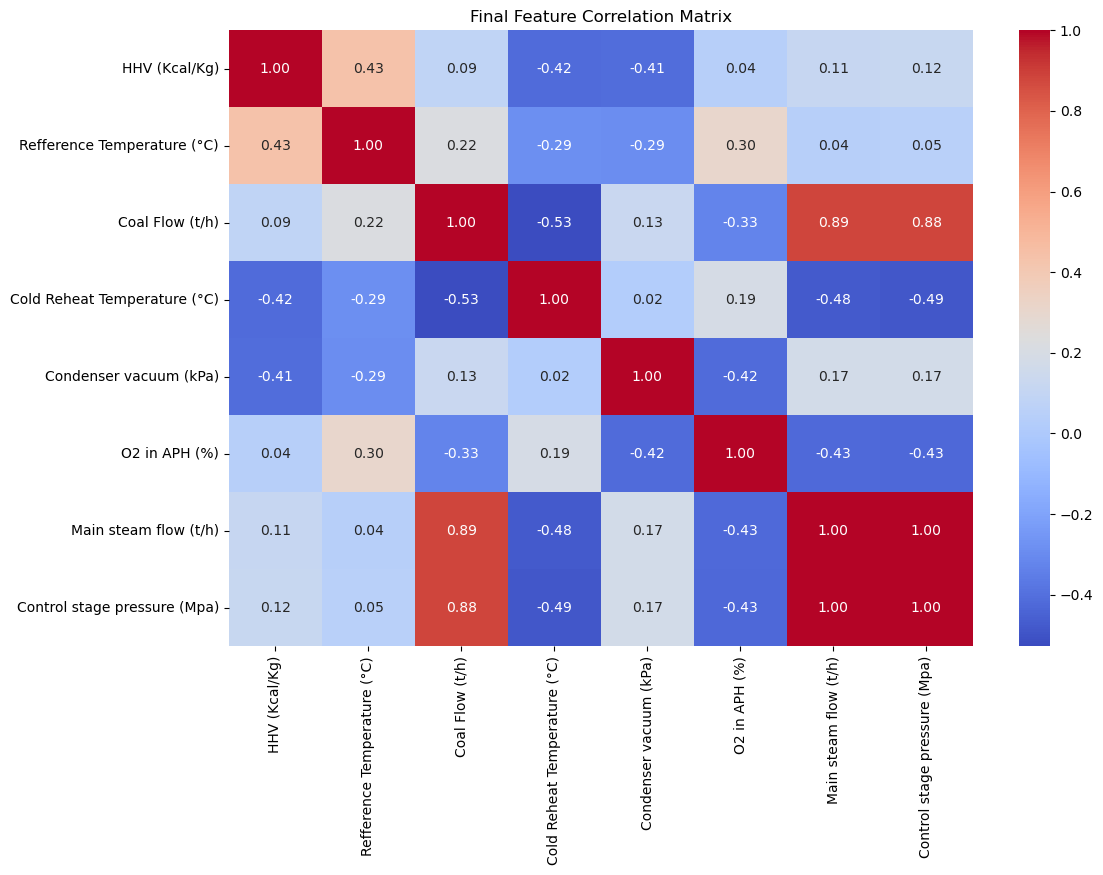


FINAL VIF ANALYSIS (Aim for VIF < 10)
                        Feature           VIF
4        Condenser vacuum (kPa)  86007.080231
3  Cold Reheat Temperature (°C)  43961.403438
7  Control stage pressure (Mpa)  24112.930357
6         Main steam flow (t/h)  22963.475700
0                 HHV (Kcal/Kg)  18472.344627
2               Coal Flow (t/h)    921.938737
1   Refference Temperature (°C)    242.069109
5                 O2 in APH (%)    104.707797

⚠️  REDUNDANSI TERDETEKSI:
- Control stage pressure (Mpa) & Main steam flow (t/h) (Corr: 1.00) -> Rekomendasi buang: Control stage pressure (Mpa)


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 2
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_boiler_eff], axis=1)
# final_dataset.to_csv('Boiler_Efficiency_Ready_Data.csv', index=False)

In [17]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'Control stage pressure (Mpa)'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
initial_selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_vetted_features_boiler = [f for f in initial_selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_vetted_features_boiler = [f for f in final_vetted_features_boiler if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_vetted_boiler = X[final_vetted_features_boiler].dropna()

In [19]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_vetted_boiler.std())

HHV (Kcal/Kg)                   42.239894
Refference Temperature (°C)      2.486496
Coal Flow (t/h)                 14.809867
Cold Reheat Temperature (°C)     1.563859
Condenser vacuum (kPa)           0.290954
O2 in APH (%)                    0.450788
Main steam flow (t/h)           79.161270
dtype: float64


In [21]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_vetted_boiler)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_vetted_boiler.columns)

# Hitung ulang VIF
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print(vif_final.sort_values(by="VIF", ascending=False))

                        Feature       VIF
2               Coal Flow (t/h)  6.217580
6         Main steam flow (t/h)  5.771875
0                 HHV (Kcal/Kg)  1.852040
3  Cold Reheat Temperature (°C)  1.746356
1   Refference Temperature (°C)  1.739153
5                 O2 in APH (%)  1.627046
4        Condenser vacuum (kPa)  1.516619


VIF < 10: Secara statistik, nilai VIF di bawah 10 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (7 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 6 fitur yang akan digunakan untuk membangun model prediksi efisiensi boiler:

Coal Flow (t/h)

Main steam flow (t/h)

HHV (Kcal/Kg)

Cold Reheat Temperature (°C)

Reference Temperature (°C)

O2 in APH (%)

Condenser Vacuum (kPa)


In [22]:
import pandas as pd
# Load dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 35)


,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369


In [24]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
'Coal Flow (t/h)',
'Main steam flow (t/h)',
'HHV (Kcal/Kg)',
'Cold Reheat Temperature (°C)',
'Refference Temperature (°C)',
'O2 in APH (%)',
'Condenser vacuum (kPa)',
'Boiler Eff (%)'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_boiler = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_boiler = df_selected_boiler.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_boiler.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_boiler.describe())

# 6. Simpan ke file Excel
file_name = '#1 final feature selected dataset 1 for boiler efficiency.xlsx'
df_selected_boiler.to_excel(file_name, index=False)
print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (549, 8)

Statistik Deskriptif:


,Coal Flow (t/h),Main steam flow (t/h),HHV (Kcal/Kg),Cold Reheat Temperature (°C),Refference Temperature (°C),O2 in APH (%),Condenser vacuum (kPa),Boiler Eff (%)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,183.049456,966.464458,4279.790127,321.865068,29.263107,3.697845,-92.825669,84.938134
std,14.809867,79.161270,42.239894,1.563859,2.486496,0.450788,0.290954,3.530716
min,155.510000,814.872691,4205.428571,318.140000,25.000000,2.380000,-93.728409,76.294873
25%,173.280000,912.481969,4261.000000,320.710000,27.500000,3.390000,-93.011729,82.548315
50%,182.450000,958.067243,4279.790127,321.865068,28.500000,3.697845,-92.825669,84.938134
75%,189.920000,1001.498154,4286.000000,322.940000,29.500000,4.000000,-92.615861,87.192305
max,259.930000,1430.466354,4389.444444,328.290000,37.000000,5.020000,-92.044818,97.255080



✅ File berhasil disimpan dengan nama: #1 final feature selected dataset 1 for boiler efficiency.xlsx


In [25]:
# Feature Selection dengan Mutual Information untuk target 2: NPHR (Kcal/Kwh)
print("\n=== Feature Selection untuk NPHR (Kcal/Kwh) ===")


=== Feature Selection untuk NPHR (Kcal/Kwh) ===


In [26]:
# Hitung skor Mutual Information
mi_scores_nphr = mutual_info_regression(X, y_nphr, random_state=42)

In [27]:
# Buat Series untuk memudahkan analisis
mi_scores_nphr_df = pd.Series(mi_scores_nphr, index=X.columns)
mi_scores_nphr_df = mi_scores_nphr_df.sort_values(ascending=False)

In [28]:
# Tampilkan fitur skor MI
print("\nfitur untuk NPHR (Kcal/Kwh) berdasarkan Mutual Information:")
print(mi_scores_nphr_df)



fitur untuk NPHR (Kcal/Kwh) berdasarkan Mutual Information:
HHV (Kcal/Kg)                                  0.445663
Main steam temperature (turbine side) (℃)      0.295022
Flue gas temperature (℃)                       0.289173
Temperature HRH                                0.248590
Cold Reheat Temperature (°C)                   0.244542
Circulating water outlet temperature (℃)       0.242337
Refference Temperature (°C)                    0.240881
Coal Flow (t/h)                                0.232972
Reheat steam temperature (boiler side) (℃)     0.228834
Reheat steam temperature (turbine side) (℃)    0.227895
O2 Out APH (%)                                 0.223517
Flue Gas in Temperature (°C)                   0.222249
Cold Reheat Pressure (Mpa)                     0.211447
Condenser vacuum (kPa)                         0.208340
Spray reheat pressure                          0.204439
Feedwater temperature (℃)                      0.196860
Nett Load (MW)                             

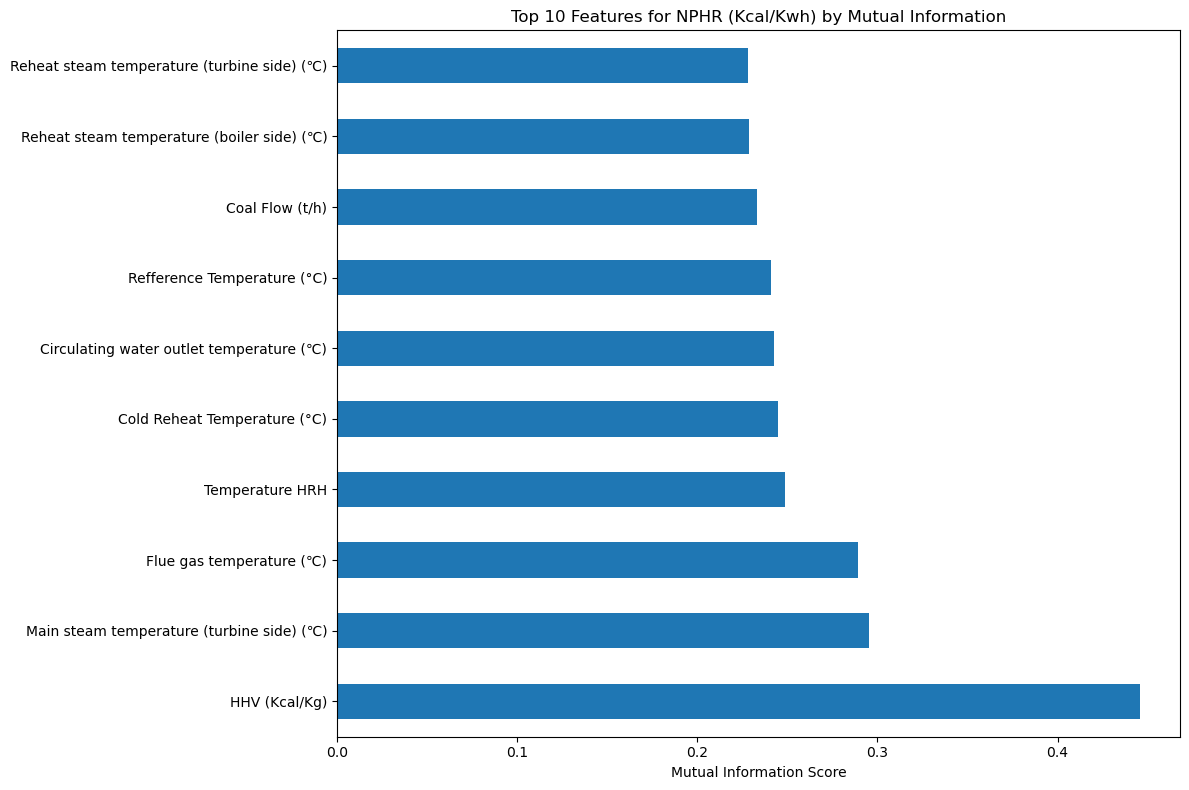

In [29]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_nphr_df.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for NPHR (Kcal/Kwh) by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [30]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET NPHR:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_NPHR = scipy_entropy(np.histogram(y_nphr, bins=20)[0] + 1e-10)
print(f"Target Entropy (NPHR): {target_entropy_NPHR:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_nphr = mi_scores_nphr_df.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_nphr:.6f}")

# Hitung juga untuk NPHR (jika belum ada)
try:
    mi_threshold_nphr = mi_scores_nphr_df.mean()
except:
    mi_threshold_nphr = mi_threshold_boiler  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR (NPHR)")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_nphr_df
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk NPHR: {mi_threshold_nphr:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_nphr:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_nphr_df > mi_threshold_nphr).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET NPHR:
----------------------------------------------------------------------------------------------------
Target Entr

In [31]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_nphr)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_nphr_df, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_nphr, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['Feedwater temperature (℃)', 'Flue gas temperature (℃)', 'Control stage pressure (Mpa)', 'Condenser vacuum (kPa)', 'Cold Reheat Pressure (Mpa)', 'Cold Reheat Temperature (°C)', 'Coal Flow (t/h)', 'Gross Load (MW)', 'Nett Load (MW)', 'Spray reheat pressure']
mRMR (Information) : ['HHV (Kcal/Kg)', 'O2 Out APH (%)', 'Flue gas temperature (℃)', 'Cold Reheat Pressure (Mpa)', 'Superheater desuperheating water flow (t/h)', 'Temperature HRH', 'Cold Reheat Temperature (°C)', 'Circulating water outlet temperature (℃)', 'Condenser vacuum (kPa)', 'Main steam temperature (turbine side) (℃)']
GA (Evolutionary)  : ['Main steam flow (t/h)', 'Main steam pressure (boiler side) (Mpa)', 'Reheat steam temperature (boiler side) (℃)', 'Feedwater temperature (℃)', 'Feedwater flow (t/h)', 'Reheat steam pressure (turbine side) (MPa)', 'Cold Reheat Pressure (Mpa)', 'Coal Flow (t/h)', 'Ne

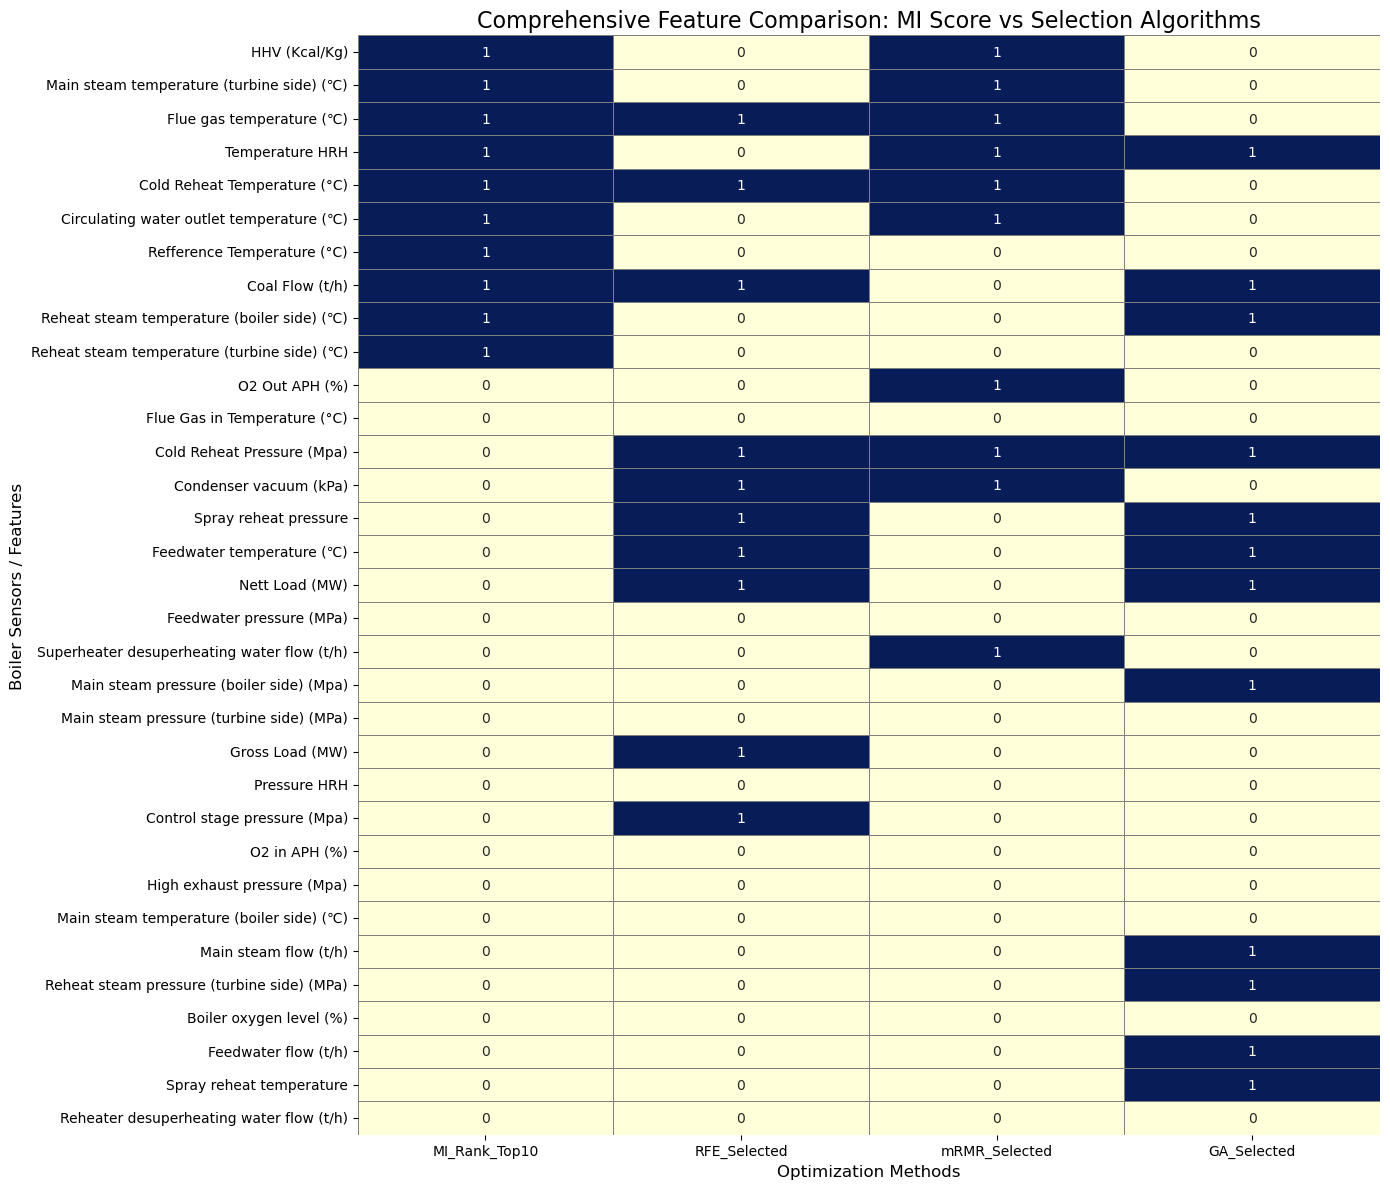


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
HHV (Kcal/Kg)                            | 0.445663   | 1      | 0     | 1     | 0     | 1
Main steam temperature (turbine side) (℃) | 0.295022   | 1      | 0     | 1     | 0     | 1
Flue gas temperature (℃)                 | 0.289173   | 1      | 1     | 1     | 0     | 2
Temperature HRH                          | 0.248590   | 1      | 0     | 1     | 1     | 2
Cold Reheat Temperature (°C)             | 0.244542   | 1      | 1     | 1     | 0     | 2
Circulating water outlet temperature (℃) | 0.242337   | 1      | 0     | 1     | 0     | 1
Refference Temperature (°C)              | 0.240881   | 1      | 0     | 0     | 0     | 0
Coal Flow (t/h)                          | 0.232972   | 1      | 1     | 0     | 1     | 2
Reheat steam temperature (boiler side) (℃) | 0.228834   | 1     

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_nphr_df.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_nphr_df

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Boiler Sensors / Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 9 fitur


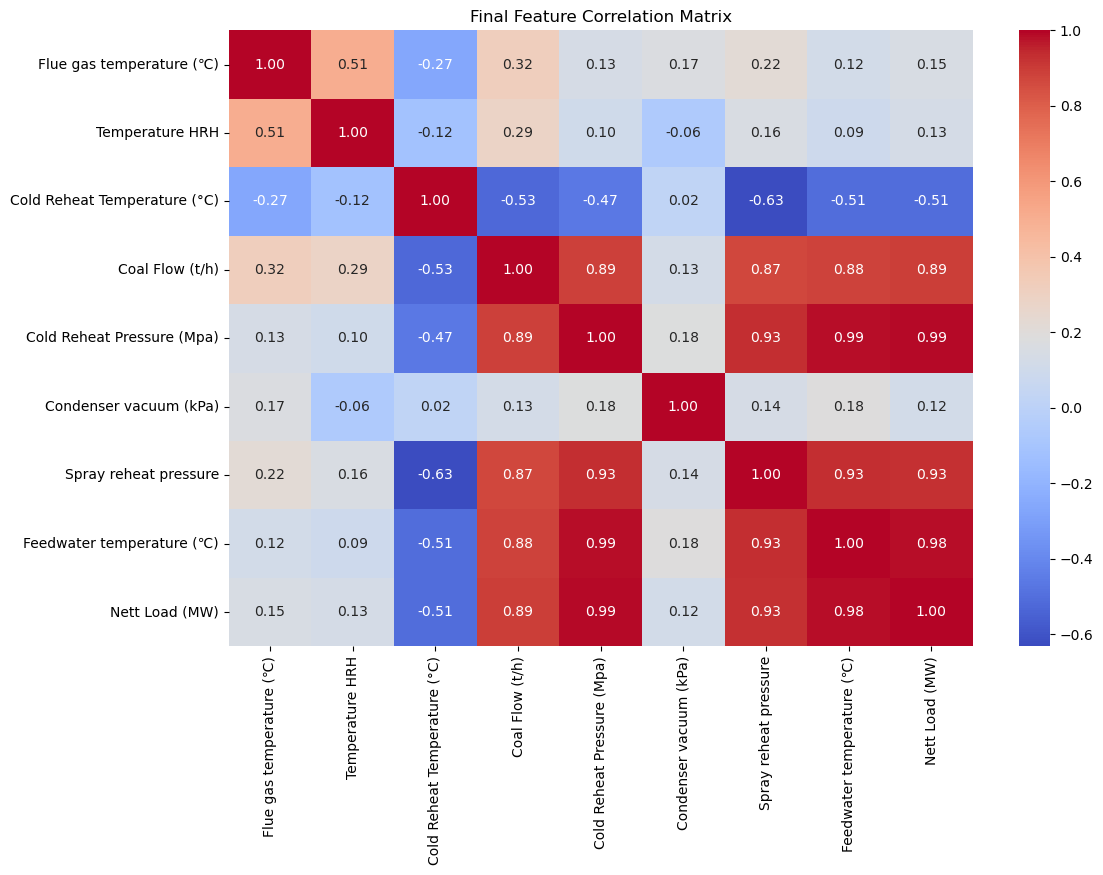


FINAL VIF ANALYSIS (Aim for VIF < 10)
                        Feature            VIF
1               Temperature HRH  373739.037936
7     Feedwater temperature (℃)  145588.928318
5        Condenser vacuum (kPa)  145011.994589
2  Cold Reheat Temperature (°C)  136949.233693
4    Cold Reheat Pressure (Mpa)   33021.621893
8                Nett Load (MW)   18051.984981
6         Spray reheat pressure    2871.530062
0      Flue gas temperature (℃)    1501.136972
3               Coal Flow (t/h)     968.125794

⚠️  REDUNDANSI TERDETEKSI:
- Spray reheat pressure & Cold Reheat Pressure (Mpa) (Corr: 0.93) -> Rekomendasi buang: Spray reheat pressure
- Feedwater temperature (℃) & Cold Reheat Pressure (Mpa) (Corr: 0.99) -> Rekomendasi buang: Feedwater temperature (℃)
- Feedwater temperature (℃) & Spray reheat pressure (Corr: 0.93) -> Rekomendasi buang: Feedwater temperature (℃)
- Nett Load (MW) & Cold Reheat Pressure (Mpa) (Corr: 0.99) -> Rekomendasi buang: Nett Load (MW)
- Nett Load (MW) & Spray r

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 2
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_nphr], axis=1)
# final_dataset.to_csv('nphr_Ready_Data.csv', index=False)

In [34]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_final.std())

Flue gas temperature (℃)         4.434272
Temperature HRH                  0.722798
Cold Reheat Temperature (°C)     1.563859
Coal Flow (t/h)                 14.809867
Cold Reheat Pressure (Mpa)       0.189057
Condenser vacuum (kPa)           0.290954
Spray reheat pressure            0.406898
Feedwater temperature (℃)        4.012463
Nett Load (MW)                  26.556100
dtype: float64


In [35]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'Spray reheat pressure', 
    'Feedwater temperature (℃)',
    'Nett Load (MW)'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
initial_selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_vetted_features_nphr = [f for f in initial_selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_vetted_features_nphr = [f for f in final_vetted_features_nphr if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_vetted_nphr = X[final_vetted_features_nphr].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_nphr = pd.DataFrame(scaler.fit_transform(X_vetted_nphr), columns=X_vetted_nphr.columns)
print(f"Fitur yang dibuang: {features_to_drop}")
print(f"Fitur yang tersisa ({len(final_vetted_features_nphr)}): {final_vetted_features_nphr}\n")

# Hitung VIF pada data yang sudah di-scale
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled_nphr.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled_nphr.values, i) for i in range(len(X_scaled_nphr.columns))]

print("="*50)
print("HASIL VIF FINAL (Dataset Stabil)")
print("="*50)
print(vif_final.sort_values(by="VIF", ascending=False))

Fitur yang dibuang: ['Spray reheat pressure', 'Feedwater temperature (℃)', 'Nett Load (MW)']
Fitur yang tersisa (6): ['Flue gas temperature (℃)', 'Temperature HRH', 'Cold Reheat Temperature (°C)', 'Coal Flow (t/h)', 'Cold Reheat Pressure (Mpa)', 'Condenser vacuum (kPa)']

HASIL VIF FINAL (Dataset Stabil)
                        Feature       VIF
3               Coal Flow (t/h)  6.544373
4    Cold Reheat Pressure (Mpa)  5.704973
0      Flue gas temperature (℃)  1.645090
1               Temperature HRH  1.498098
2  Cold Reheat Temperature (°C)  1.456279
5        Condenser vacuum (kPa)  1.133328


VIF < 10: Secara statistik, nilai VIF di bawah 10 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (5 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 5 fitur yang akan digunakan untuk membangun model prediksi nphr:

Coal Flow (t/h)

Cold Reheat Pressure (Mpa)

Cold Reheat Temperature (°C)

Flue gas temperature (℃)

Condenser Vacuum (kPa)

In [36]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 35)


,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369


In [37]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
    'Coal Flow (t/h)',
    'Cold Reheat Pressure (Mpa)',
    'Flue gas temperature (℃)',
    'Temperature HRH',
    'Cold Reheat Temperature (°C)',
    'Condenser vacuum (kPa)',
    'NPHR (Kcal/Kwh)'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_nphr = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_nphr = df_selected_nphr.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_nphr.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_nphr.describe())

# 6. Simpan ke file Excel
file_name = '#1 final feature selected dataset 1 for nphr.xlsx'
df_selected_nphr.to_excel(file_name, index=False)

print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (549, 7)

Statistik Deskriptif:


,Coal Flow (t/h),Cold Reheat Pressure (Mpa),Flue gas temperature (℃),Temperature HRH,Cold Reheat Temperature (°C),Condenser vacuum (kPa),NPHR (Kcal/Kwh)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,183.049456,2.439748,130.919396,566.482602,321.865068,-92.825669,2505.527823
std,14.809867,0.189057,4.434272,0.722798,1.563859,0.290954,93.809060
min,155.510000,2.060000,121.206816,564.090000,318.140000,-93.728409,2191.472033
25%,173.280000,2.310000,127.518962,566.090000,320.710000,-93.011729,2455.553521
50%,182.450000,2.420000,130.919396,566.490000,321.865068,-92.825669,2508.676793
75%,189.920000,2.520000,134.054544,566.930000,322.940000,-92.615861,2568.594923
max,259.930000,3.560000,143.387231,568.670000,328.290000,-92.044818,2752.407005



✅ File berhasil disimpan dengan nama: #1 final feature selected dataset 1 for nphr.xlsx
